# Compare all server evaluations

This notebook reads all evaluation results below `eva_server/evaluation` and compares PIN, two-output, and one-output models in one place.

It handles mixed folder layouts: some folders contain one model, some may contain multiple models. Model display names are normalized to `MMDD-HHMM_arch` where possible, for example `0704-0227_pin`.

Outputs are written to `eva_server/model_comparison`.

Use the **Choose and rename models** section after loading the summaries to keep only the models you want in the diagrams and to assign shorter display names.

In [2]:
from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
try:
    import pandas as pd
except ImportError as exc:
    raise ImportError("This notebook needs pandas. Install it with: uv add pandas") from exc

## Configuration

In [3]:
EVA_ROOT = Path("eva_server/evaluation")
OUTPUT_DIR = Path("eva_server/model_comparison/allmodels")
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Ranking is primarily based on spot_recognition_mean because it combines Dice and RMSE.
# The tie breakers make ranking deterministic and favor stronger mask overlap and lower intensity error.
RANK_PRIMARY = "spot_recognition_mean"
TOP_N = 3

SPOT_BIN_ORDER = ["<50%", "50-70%", "70-90%", ">90%"]
SPOT_BIN_LABELS = {
    "<50%_fraction": "below 50%",
    "50-70%_fraction": "50-70%",
    "70-90%_fraction": "70-90%",
    ">90%_fraction": "above 90%",
}
SPOT_BIN_COLORS = {
    "<50%_fraction": "#d8e2ee",
    "50-70%_fraction": "#9bb8d4",
    "70-90%_fraction": "#4f86b9",
    ">90%_fraction": "#1f4e79",
}
ARCH_ORDER = ["oneoutput", "twooutput", "pin", "unknown"]
ARCH_COLORS = {
    "oneoutput": "#0072B2",
    "twooutput": "#009E73",
    "pin": "#D55E00",
    "unknown": "#666666",
}
COLOR = {
    "blue": "#0072B2",
    "sky": "#56B4E9",
    "green": "#009E73",
    "orange": "#E69F00",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "gray": "#666666",
}

# Keep model colors consistent with the loss-curve notebook.
MODEL_COLORS = {
    # Two-output models — green
    "two-output L1": "#15803D",
    "two-output L1 batch 100": "#16A34A",
    "two-output L1 base-channel 32": "#4D7C0F",
    "two-output Reconstruction Loss": "#0F766E",
    "two-output Tversky Loss": "#65A30D",
    "two-output Tversky Loss small Dataset": "#84A832",

    # One-output models — ochre / golden brown
    "one-output Tversky Loss": "#A16207",
    "one-output Loss": "#D08A18",

    # Multi-head BCE/MSE — purple / plum
    "multi-head BCE/MSE Loss": "#7E3A8A",
    "multi-head BCE/MSE Loss small Dataset": "#A15AAD",

    # Multi-head Tversky — pink / magenta
    "multi-head Tversky Loss": "#C0266D",
    "multi-head Tversky Loss base-channel 32": "#DB4B83",
    "multi-head Tversky Loss batch 100": "#A61E5C",
    "multi-head Tversky Loss lr 3e-04": "#E35D94",
    "multi-head Tversky Loss lr 5e-05": "#8F174F",
    "multi-head Tversky Loss batch 20": "#B83A75",
}
DEFAULT_MODEL_COLOR = COLOR["gray"]
THESIS_BLUE_CMAP = "Blues"


def model_color(model_display):
    return MODEL_COLORS.get(model_display, DEFAULT_MODEL_COLOR)


def color_model_ticklabels(ax, axis="y"):
    ticklabels = ax.get_yticklabels() if axis == "y" else ax.get_xticklabels()
    for tick in ticklabels:
        tick.set_color(model_color(tick.get_text()))

mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "Latin Modern Roman", "cmr10", "STIX Two Text", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

## Helpers

In [4]:
def savefig(fig, name):
    png = FIGURE_DIR / f"{name}.png"
    pdf = FIGURE_DIR / f"{name}.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print(f"saved {png}")
    print(f"saved {pdf}")


def coerce_numeric(df):
    for column in df.columns:
        if df[column].dtype == object:
            converted = pd.to_numeric(df[column], errors="coerce")
            if converted.notna().sum() > 0 and converted.notna().sum() >= df[column].notna().sum() * 0.75:
                df[column] = converted
    return df


def infer_arch_from_path(path, model_name=""):
    text = f"{path} {model_name}".lower()
    if "oneoutput" in text or "one_output" in text:
        return "oneoutput"
    if "twooutput" in text or "twooutputs" in text or "twoouts" in text or "two_output" in text:
        return "twooutput"
    if "pin" in text:
        return "pin"
    return "unknown"


def extract_mmdd_hhmm(*texts):
    joined = " ".join(str(text) for text in texts)
    patterns = [
        r"2026(?P<mm>\d{2})(?P<dd>\d{2})[-_](?P<hh>\d{2})(?P<mi>\d{2})",
        r"(?P<mm>\d{2})(?P<dd>\d{1,2})[-_](?P<hh>\d{2})(?P<mi>\d{2})",
    ]
    for pattern in patterns:
        match = re.search(pattern, joined)
        if match:
            return f"{match.group('mm')}{match.group('dd')}-{match.group('hh')}{match.group('mi')}"
    return None


def model_display_name(model, source_dir, arch):
    stamp = extract_mmdd_hhmm(model, source_dir)
    if stamp is None:
        base = Path(source_dir).name.re["Computer Modern Roman", "STIX Two Text", "DejaVu Serif"]
        return f"{base}_{arch}"
    return f"{stamp}_{arch}"


def make_unique_model_display(display_name, source_dir, ambiguous_labels):
    if display_name in set(ambiguous_labels):
        return f"{display_name}__{Path(source_dir).name}"
    return display_name


def dataset_label(experiment):
    text = str(experiment).replace(".h5", "").replace("_logtif", "")
    if text in {"Al_segvol", "Al"}:
        return "Al"
    if text.startswith("Al_deformed_LoG"):
        return "Al_deformed_LoG"
    if text.startswith("Al_big_grains"):
        return "Al_big_grains"
    if text.startswith("Al_small_grains"):
        return "Al_small_grains"
    if text.startswith("Cu"):
        return "Cu"
    if text.startswith("IN718_twins"):
        return "IN718_twins"
    if text.startswith("Iron_deformed"):
        return "Iron_deformed"
    if text.startswith("Iron"):
        return "Iron"
    if text.startswith("Ti7Al"):
        return "Ti7Al"
    return text


def read_csv_if_nonempty(path):
    path = Path(path)
    if path.exists() and path.stat().st_size > 0:
        return coerce_numeric(pd.read_csv(path))
    return pd.DataFrame()


def find_metric_files(root):
    root = Path(root)
    return {
        "model": sorted(root.rglob("*model_separation_metrics_5000.csv")),
        "dataset": sorted(root.rglob("*dataset_separation_metrics_5000.csv")),
        "spot": sorted(root.rglob("*spot_separation_metrics_5000.csv")),
        "counter": sorted(root.rglob("*spot_counter_5000.csv")),
        "timing": sorted(root.rglob("*evaluation_timing_5000.csv")),
        "donor": sorted(root.rglob("*donor_separation_metrics_5000.csv")),
    }


## Load all evaluation CSVs

In [5]:
files = find_metric_files(EVA_ROOT)
for kind, paths in files.items():
    print(f"{kind:8s}: {len(paths)} file(s)")
    for path in paths:
        print("  ", path)

model_frames = []
for path in files["model"]:
    df = read_csv_if_nonempty(path)
    if df.empty:
        continue
    source_dir = str(path.parent)
    df["source_dir"] = source_dir
    df["source_file"] = str(path)
    df["architecture"] = [infer_arch_from_path(source_dir, model) for model in df["model"]]
    df["model_display"] = [model_display_name(model, source_dir, arch) for model, arch in zip(df["model"], df["architecture"])]
    if "experiment" in df.columns:
        df["dataset"] = df["experiment"].map(dataset_label)
    model_frames.append(df)

sample_df = pd.concat(model_frames, ignore_index=True) if model_frames else pd.DataFrame()
AMBIGUOUS_MODEL_LABELS = []
if not sample_df.empty:
    sample_df["model_display_base"] = sample_df["model_display"]
    distinct_runs = sample_df[["model_display", "model", "source_dir"]].drop_duplicates()
    duplicate_counts = distinct_runs.groupby("model_display")["source_dir"].nunique()
    AMBIGUOUS_MODEL_LABELS = duplicate_counts[duplicate_counts > 1].index.tolist()
    sample_df["model_display"] = [
        make_unique_model_display(display, source_dir, AMBIGUOUS_MODEL_LABELS)
        for display, source_dir in zip(sample_df["model_display_base"], sample_df["source_dir"])
    ]

print("sample_df", sample_df.shape)
if AMBIGUOUS_MODEL_LABELS:
    print("Ambiguous model labels were made unique with a folder suffix:", ", ".join(AMBIGUOUS_MODEL_LABELS))
if not sample_df.empty:
    display(sample_df[["model_display", "model_display_base", "architecture", "model", "source_dir"]].drop_duplicates().sort_values("model_display"))


model   : 15 file(s)
   eva_server/evaluation/oneoutput/0702_oneoutput/oneoutput_model_separation_metrics_5000.csv
   eva_server/evaluation/oneoutput/tversky/oneoutput_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/batch20/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/dif_lr/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/pin2/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/pin_base320722/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/pins/pin_batch100/pin_model_separation_metrics_5000.csv
   eva_server/evaluation/twooutput/0630_2045_twooutput/model_separation_metrics_5000.csv
   eva_server/evaluation/twooutput/0630_2045_twooutputs/model_separation_metrics_5000.csv
   eva_server/evaluation/twooutput/0707_twooutputs/model_separation_metrics_5000.csv
   eva_server/evaluation/twooutput/0707_twooutputs_second_edition/model_separation_metrics_5000.csv
   eva_server/evaluation/twooutput/0717-0844_t

,model_display,model_display_base,architecture,model,source_dir
50000,0630-2045_twooutput__0630_2045_twooutput,0630-2045_twooutput,twooutput,final_20260630-204540_augmented_spot_patches_e...,eva_server/evaluation/twooutput/0630_2045_twoo...
55000,0630-2045_twooutput__0630_2045_twooutputs,0630-2045_twooutput,twooutput,final_20260630-204540_augmented_spot_patches_e...,eva_server/evaluation/twooutput/0630_2045_twoo...
0,0702-1451_oneoutput,0702-1451_oneoutput,oneoutput,final_20260702-145153_augmented_spots_train_e2...,eva_server/evaluation/oneoutput/0702_oneoutput
85000,0703-2013_twooutput,0703-2013_twooutput,twooutput,final_20260703-201335_augmented_spot_patches_e...,eva_server/evaluation/twooutput/twooutput
25000,0704-0227_pin,0704-0227_pin,pin,final_20260704-022731_augmented_spot_patches_w...,eva_server/evaluation/pins/pin2
60000,0707-1118_twooutput__0707_twooutputs,0707-1118_twooutput,twooutput,final_20260707-111849_twoouts_augmented_spots_...,eva_server/evaluation/twooutput/0707_twooutputs
65000,0707-1118_twooutput__0707_twooutputs_second_ed...,0707-1118_twooutput,twooutput,final_20260707-111849_twoouts_augmented_spots_...,eva_server/evaluation/twooutput/0707_twooutput...
30000,0709-1413_pin,0709-1413_pin,pin,final_20260709-141342_augmented_spots_train_pi...,eva_server/evaluation/pins/pin2
35000,0710-1637_pin,0710-1637_pin,pin,final_20260710-163719_augmented_spots_train_e2...,eva_server/evaluation/pins/pin2
70000,0717-0844_twooutput,0717-0844_twooutput,twooutput,final_20260717-084426_augmented_spots_train_e2...,eva_server/evaluation/twooutput/0717-0844_twoo...


## Build model-level summary

In [6]:
def aggregate_model_metrics(sample_df):
    metric_cols = [
        "dice_mean", "iou_mean", "rmse_mean", "nrmse_mean",
        "soft_intensity_dice_mean", "integrated_intensity_abs_relative_error_mean",
        "spot_recognition_mean", "reconstruction_rmse",
    ]
    metric_cols = [col for col in metric_cols if col in sample_df.columns]
    agg = {col: (col, "mean") for col in metric_cols}
    agg.update({
        "n_samples": ("sample_name", "count"),
        "model": ("model", "first"),
        "model_path": ("model_path", "first"),
        "architecture": ("architecture", "first"),
        "source_dir": ("source_dir", "first"),
        "source_file": ("source_file", "first"),
    })
    summary = sample_df.groupby("model_display").agg(**agg).reset_index()
    if "spot_recognition_mean" in sample_df.columns:
        p10 = sample_df.groupby("model_display")["spot_recognition_mean"].quantile(0.10).rename("spot_recognition_p10")
        summary = summary.join(p10, on="model_display")
    if "dice_mean" in sample_df.columns:
        p10 = sample_df.groupby("model_display")["dice_mean"].quantile(0.10).rename("dice_p10")
        summary = summary.join(p10, on="model_display")
    return summary


model_summary = aggregate_model_metrics(sample_df) if not sample_df.empty else pd.DataFrame()

# Attach timing, if available.
timing_frames = []
for path in files["timing"]:
    df = read_csv_if_nonempty(path)
    if df.empty:
        continue
    source_dir = str(path.parent)
    df["source_dir"] = source_dir
    df["architecture"] = [infer_arch_from_path(source_dir, model) for model in df["model"]]
    df["model_display_base"] = [model_display_name(model, source_dir, arch) for model, arch in zip(df["model"], df["architecture"])]
    df["model_display"] = [
        make_unique_model_display(display, source_dir, AMBIGUOUS_MODEL_LABELS)
        for display in df["model_display_base"]
    ]
    timing_frames.append(df)
timing_df = pd.concat(timing_frames, ignore_index=True) if timing_frames else pd.DataFrame()
if not timing_df.empty and not model_summary.empty:
    timing_cols = ["model_display", "total_eval_seconds", "seconds_per_sample", "seconds_per_spot", "samples_per_second", "spots_per_second"]
    timing_cols = [col for col in timing_cols if col in timing_df.columns]
    model_summary = model_summary.merge(timing_df[timing_cols].drop_duplicates("model_display"), on="model_display", how="left")
model_summary.to_csv(OUTPUT_DIR / "all_model_summary.csv", index=False)
display(model_summary.sort_values(RANK_PRIMARY, ascending=False))


,model_display,dice_mean,iou_mean,rmse_mean,nrmse_mean,soft_intensity_dice_mean,integrated_intensity_abs_relative_error_mean,spot_recognition_mean,reconstruction_rmse,n_samples,...,architecture,source_dir,source_file,spot_recognition_p10,dice_p10,total_eval_seconds,seconds_per_sample,seconds_per_spot,samples_per_second,spots_per_second
8,0710-1637_pin,0.956160,0.919572,0.037371,192.504668,0.983797,25856.774330,0.930765,NaN,5000,...,pin,eva_server/evaluation/pins/pin2,eva_server/evaluation/pins/pin2/pin_model_sepa...,0.889941,0.925624,48.383891,0.009677,0.004838,103.340179,206.680358
18,0802-1237_pin,0.937926,0.889561,0.039717,181.166040,0.977032,24356.193578,0.912692,NaN,5000,...,pin,eva_server/evaluation/pins/batch20,eva_server/evaluation/pins/batch20/pin_model_s...,0.839708,0.892099,49.003572,0.009801,0.004900,102.033378,204.066757
17,0729-0433_pin,0.934707,0.885838,0.040669,435.688302,0.973128,51550.007689,0.908481,NaN,5000,...,pin,eva_server/evaluation/pins/dif_lr,eva_server/evaluation/pins/dif_lr/pin_model_se...,0.826114,0.885797,77.266147,0.015453,0.007727,64.711393,129.422786
14,0721-2040_pin,0.933048,0.881404,0.041070,189.979277,0.973432,25351.090474,0.906833,NaN,5000,...,pin,eva_server/evaluation/pins/pin_batch100,eva_server/evaluation/pins/pin_batch100/pin_mo...,0.826762,0.886501,115.766900,0.023153,0.011577,43.190238,86.380477
11,0720-1538_pin,0.929609,0.875962,0.042404,191.751274,0.974258,25299.596815,0.904264,NaN,5000,...,pin,eva_server/evaluation/pins/pin_base320722,eva_server/evaluation/pins/pin_base320722/pin_...,0.833615,0.887328,48.127829,0.009626,0.004813,103.889998,207.779995
16,0728-0732_pin,0.908816,0.842982,0.050375,133.572508,0.972419,14001.426816,0.885455,NaN,5000,...,pin,eva_server/evaluation/pins/dif_lr,eva_server/evaluation/pins/dif_lr/pin_model_se...,0.805290,0.828489,86.237050,0.017247,0.008624,57.979720,115.959440
7,0709-1413_pin,0.821710,0.727255,0.127231,100.792222,0.878286,12862.700654,0.756464,NaN,5000,...,pin,eva_server/evaluation/pins/pin2,eva_server/evaluation/pins/pin2/pin_model_sepa...,0.589703,0.636432,48.302650,0.009661,0.004830,103.513989,207.027978
5,0707-1118_twooutput__0707_twooutputs,0.951594,0.911721,0.666575,3.058524,NaN,3.509644,0.672344,NaN,5000,...,twooutput,eva_server/evaluation/twooutput/0707_twooutputs,eva_server/evaluation/twooutput/0707_twooutput...,0.639923,0.912453,61.407476,0.012281,0.006141,81.423311,162.846622
6,0707-1118_twooutput__0707_twooutputs_second_ed...,0.951594,0.911721,0.666575,3.058524,0.535786,3.509644,0.672344,NaN,5000,...,twooutput,eva_server/evaluation/twooutput/0707_twooutput...,eva_server/evaluation/twooutput/0707_twooutput...,0.639923,0.912453,48.115499,0.009623,0.004812,103.916620,207.833241
2,0702-1451_oneoutput,0.681937,0.546975,0.118094,0.475481,0.860408,0.194841,0.642630,1.445949e-10,5000,...,oneoutput,eva_server/evaluation/oneoutput/0702_oneoutput,eva_server/evaluation/oneoutput/0702_oneoutput...,0.473306,0.489614,48.545684,0.009709,0.004855,102.995767,205.991535


## Choose and rename models

Edit this cell to decide which models appear in the tables and figures. Leave `SELECTED_MODELS` empty to use all models. Use the names shown in the `available_models` table.

In [15]:
# --- User selection: edit these two variables ---
# Use model_display names from the available_models table below.
SELECTED_MODELS = [
    "0702-1451_oneoutput",
    "0727-1529_oneoutput",
    "0710-1637_pin",
    "0709-1413_pin",
    "0721-2040_pin",
    "0720-1538_pin",
    "0704-0227_pin",
    "0729-0433_pin",
    "0728-0732_pin",
    "0802-1237_pin",
    "0719-0847_twooutput",
    "0721-1027_twooutput",
    "0707-1118_twooutput__0707_twooutputs_second_edition",
    "0703-2013_twooutput",
    "0721-0111_twooutput",
    "0717-0844_twooutput",  
    
]

# Rename long/internal labels for prettier plots. Keys are current model_display names;
# values are the labels that should appear in figures and exported CSVs.
# These labels match the loss-curve notebook.
MODEL_RENAMES = {
    "0710-1637_pin": "multi-head Tversky Loss",
    "0709-1413_pin": "multi-head BCE/MSE Loss",
    "0721-2040_pin": "multi-head Tversky Loss batch 100",
    "0720-1538_pin": "multi-head Tversky Loss base-channel 32",
    "0704-0227_pin": "multi-head BCE/MSE Loss small Dataset",
    "0729-0433_pin": "multi-head Tversky Loss lr 3e-04",
    "0728-0732_pin": "multi-head Tversky Loss lr 5e-05",
    "0802-1237_pin": "multi-head Tversky Loss batch 20",
    "0702-1451_oneoutput": "one-output Loss",
    "0727-1529_oneoutput": "one-output Tversky Loss",
    "0719-0847_twooutput": "two-output L1 batch 100",
    "0721-1027_twooutput": "two-output Reconstruction Loss",
    "0721-0111_twooutput": "two-output L1",
    "0717-0844_twooutput": "two-output L1 base-channel 32",
    "0707-1118_twooutput__0707_twooutputs_second_edition": "two-output Tversky Loss",
    "0703-2013_twooutput": "two-output Tversky Loss small Dataset"
}

def apply_model_selection_and_renaming(df, display_col="model_display"):
    if df.empty or display_col not in df.columns:
        return df.copy()

    out = df.copy()
    if SELECTED_MODELS:
        selected = set(SELECTED_MODELS)
        known = set(out[display_col].dropna().unique())
        missing = sorted(selected.difference(known))
        if missing:
            print("Warning: selected model names not found:", ", ".join(missing))
        out = out[out[display_col].isin(selected)].copy()

    if MODEL_RENAMES:
        out[display_col] = out[display_col].replace(MODEL_RENAMES)

    if display_col == "model_display":
        out["model_color"] = out[display_col].map(model_color)

    return out


def show_selected_model_names(df, display_col="model_display"):
    names = sorted(df[display_col].dropna().unique()) if display_col in df.columns else []
    print(f"Using {len(names)} model(s):")
    for name in names:
        print(" -", name)


available_cols = ["model_display", "architecture", "model", "source_dir"]
available_cols = [col for col in available_cols if col in model_summary.columns]
available_models = model_summary[available_cols].drop_duplicates().sort_values("model_display")
display(available_models)

# Keep originals so you can rerun only this cell after changing SELECTED_MODELS/MODEL_RENAMES.
if "model_summary_all" not in globals():
    model_summary_all = model_summary.copy()
if "sample_df_all" not in globals():
    sample_df_all = sample_df.copy()
if "timing_df_all" not in globals():
    timing_df_all = timing_df.copy() if "timing_df" in globals() else pd.DataFrame()

model_summary = apply_model_selection_and_renaming(model_summary_all)
sample_df = apply_model_selection_and_renaming(sample_df_all)
timing_df = apply_model_selection_and_renaming(timing_df_all)

if SELECTED_MODELS and model_summary.empty:
    raise ValueError("SELECTED_MODELS removed every model. Check the names in available_models above.")

renamed_counts = model_summary["model_display"].value_counts() if "model_display" in model_summary.columns else pd.Series(dtype=int)
duplicate_renames = renamed_counts[renamed_counts > 1]
if not duplicate_renames.empty:
    print("Warning: these display names are duplicated after renaming:")
    display(duplicate_renames.rename("count").reset_index().rename(columns={"index": "model_display"}))

show_selected_model_names(model_summary)
display(model_summary.sort_values(RANK_PRIMARY, ascending=False))

,model_display,architecture,model,source_dir
7,multi-head BCE/MSE Loss,pin,final_20260709-141342_augmented_spots_train_pi...,eva_server/evaluation/pins/pin2
4,multi-head BCE/MSE Loss small Dataset,pin,final_20260704-022731_augmented_spot_patches_w...,eva_server/evaluation/pins/pin2
11,multi-head Tversky Loss base-channel 32,pin,final_20260720-153845_augmented_spots_train_e2...,eva_server/evaluation/pins/pin_base320722
14,multi-head Tversky Loss batch 100,pin,final_20260721-204034_augmented_spots_train_e2...,eva_server/evaluation/pins/pin_batch100
18,multi-head Tversky Loss batch 20,pin,final_20260802-123726_augmented_spots_train_e2...,eva_server/evaluation/pins/batch20
17,multi-head Tversky Loss lr 3e-04,pin,final_20260729-043315_augmented_spots_train_e2...,eva_server/evaluation/pins/dif_lr
16,multi-head Tversky Loss lr 5e-05,pin,final_20260728-073240_augmented_spots_train_e2...,eva_server/evaluation/pins/dif_lr
2,one-output Loss,oneoutput,final_20260702-145153_augmented_spots_train_e2...,eva_server/evaluation/oneoutput/0702_oneoutput
12,two-output L1,twooutput,final_20260721-011126_augmented_spots_train_e2...,eva_server/evaluation/twooutput/0721twooutput_...
9,two-output L1 base-channel 32,twooutput,final_20260717-084426_augmented_spots_train_e2...,eva_server/evaluation/twooutput/0717-0844_twoo...


Using 16 model(s):
 - multi-head BCE/MSE Loss
 - multi-head BCE/MSE Loss small Dataset
 - multi-head Tversky Loss
 - multi-head Tversky Loss base-channel 32
 - multi-head Tversky Loss batch 100
 - multi-head Tversky Loss batch 20
 - multi-head Tversky Loss lr 3e-04
 - multi-head Tversky Loss lr 5e-05
 - one-output Loss
 - one-output Tversky Loss
 - two-output L1
 - two-output L1 base-channel 32
 - two-output L1 batch 100
 - two-output Reconstruction Loss
 - two-output Tversky Loss
 - two-output Tversky Loss small Dataset


,model_display,dice_mean,iou_mean,rmse_mean,nrmse_mean,soft_intensity_dice_mean,integrated_intensity_abs_relative_error_mean,spot_recognition_mean,reconstruction_rmse,n_samples,...,source_dir,source_file,spot_recognition_p10,dice_p10,total_eval_seconds,seconds_per_sample,seconds_per_spot,samples_per_second,spots_per_second,model_color
8,multi-head Tversky Loss,0.956160,0.919572,0.037371,192.504668,0.983797,25856.774330,0.930765,NaN,5000,...,eva_server/evaluation/pins/pin2,eva_server/evaluation/pins/pin2/pin_model_sepa...,0.889941,0.925624,48.383891,0.009677,0.004838,103.340179,206.680358,#C0266D
18,multi-head Tversky Loss batch 20,0.937926,0.889561,0.039717,181.166040,0.977032,24356.193578,0.912692,NaN,5000,...,eva_server/evaluation/pins/batch20,eva_server/evaluation/pins/batch20/pin_model_s...,0.839708,0.892099,49.003572,0.009801,0.004900,102.033378,204.066757,#B83A75
17,multi-head Tversky Loss lr 3e-04,0.934707,0.885838,0.040669,435.688302,0.973128,51550.007689,0.908481,NaN,5000,...,eva_server/evaluation/pins/dif_lr,eva_server/evaluation/pins/dif_lr/pin_model_se...,0.826114,0.885797,77.266147,0.015453,0.007727,64.711393,129.422786,#E35D94
14,multi-head Tversky Loss batch 100,0.933048,0.881404,0.041070,189.979277,0.973432,25351.090474,0.906833,NaN,5000,...,eva_server/evaluation/pins/pin_batch100,eva_server/evaluation/pins/pin_batch100/pin_mo...,0.826762,0.886501,115.766900,0.023153,0.011577,43.190238,86.380477,#A61E5C
11,multi-head Tversky Loss base-channel 32,0.929609,0.875962,0.042404,191.751274,0.974258,25299.596815,0.904264,NaN,5000,...,eva_server/evaluation/pins/pin_base320722,eva_server/evaluation/pins/pin_base320722/pin_...,0.833615,0.887328,48.127829,0.009626,0.004813,103.889998,207.779995,#DB4B83
16,multi-head Tversky Loss lr 5e-05,0.908816,0.842982,0.050375,133.572508,0.972419,14001.426816,0.885455,NaN,5000,...,eva_server/evaluation/pins/dif_lr,eva_server/evaluation/pins/dif_lr/pin_model_se...,0.805290,0.828489,86.237050,0.017247,0.008624,57.979720,115.959440,#8F174F
7,multi-head BCE/MSE Loss,0.821710,0.727255,0.127231,100.792222,0.878286,12862.700654,0.756464,NaN,5000,...,eva_server/evaluation/pins/pin2,eva_server/evaluation/pins/pin2/pin_model_sepa...,0.589703,0.636432,48.302650,0.009661,0.004830,103.513989,207.027978,#7E3A8A
6,two-output Tversky Loss,0.951594,0.911721,0.666575,3.058524,0.535786,3.509644,0.672344,NaN,5000,...,eva_server/evaluation/twooutput/0707_twooutput...,eva_server/evaluation/twooutput/0707_twooutput...,0.639923,0.912453,48.115499,0.009623,0.004812,103.916620,207.833241,#65A30D
2,one-output Loss,0.681937,0.546975,0.118094,0.475481,0.860408,0.194841,0.642630,1.445949e-10,5000,...,eva_server/evaluation/oneoutput/0702_oneoutput,eva_server/evaluation/oneoutput/0702_oneoutput...,0.473306,0.489614,48.545684,0.009709,0.004855,102.995767,205.991535,#D08A18
4,multi-head BCE/MSE Loss small Dataset,0.647576,0.542292,0.145573,439.263558,0.843826,64284.942277,0.617256,NaN,5000,...,eva_server/evaluation/pins/pin2,eva_server/evaluation/pins/pin2/pin_model_sepa...,0.454210,0.445703,48.462001,0.009692,0.004846,103.173619,206.347237,#A15AAD


## Sanity checks

In [16]:
if sample_df.empty:
    raise ValueError(f"No model metrics found below {EVA_ROOT}")

# Same display name can happen if two folders/models share the same timestamp and architecture.
display_counts = model_summary["model_display"].value_counts()
ambiguous_displays = display_counts[display_counts > 1]
if not ambiguous_displays.empty:
    print("Ambiguous display names found. Consider adding a suffix manually:")
    display(model_summary[model_summary["model_display"].isin(ambiguous_displays.index)][["model_display", "model", "source_dir"]])
else:
    print("No duplicated display names.")

required = ["dice_mean", "iou_mean", "rmse_mean", "spot_recognition_mean"]
missing_by_model = []
for _, row in model_summary.iterrows():
    missing = [col for col in required if col not in model_summary.columns or pd.isna(row.get(col))]
    if missing:
        missing_by_model.append({"model_display": row["model_display"], "missing": ", ".join(missing)})
if missing_by_model:
    print("Models with missing core metrics:")
    display(pd.DataFrame(missing_by_model))
else:
    print("All models have the core comparison metrics.")

No duplicated display names.
All models have the core comparison metrics.


## Ranking and Top 3

In [17]:
rank_df = model_summary.copy()
rank_df = rank_df.dropna(subset=[RANK_PRIMARY])
rank_df = rank_df.sort_values(
    by=[RANK_PRIMARY, "dice_mean", "iou_mean", "nrmse_mean"],
    ascending=[False, False, False, True],
).reset_index(drop=True)
rank_df["rank"] = np.arange(1, len(rank_df) + 1)
rank_columns = [
    "rank", "model_display", "architecture", "spot_recognition_mean", "dice_mean", "iou_mean",
    "rmse_mean", "nrmse_mean", "soft_intensity_dice_mean", "integrated_intensity_abs_relative_error_mean",
    "seconds_per_sample", "n_samples", "model", "source_dir",
]
rank_columns = [col for col in rank_columns if col in rank_df.columns]
rank_df[rank_columns].to_csv(OUTPUT_DIR / "model_ranking.csv", index=False)
top3 = rank_df.head(TOP_N)[rank_columns]
top3.to_csv(OUTPUT_DIR / "top3_models.csv", index=False)
display(top3)

,rank,model_display,architecture,spot_recognition_mean,dice_mean,iou_mean,rmse_mean,nrmse_mean,soft_intensity_dice_mean,integrated_intensity_abs_relative_error_mean,seconds_per_sample,n_samples,model,source_dir
0,1,multi-head Tversky Loss,pin,0.930765,0.956160,0.919572,0.037371,192.504668,0.983797,25856.774330,0.009677,5000,final_20260710-163719_augmented_spots_train_e2...,eva_server/evaluation/pins/pin2
1,2,multi-head Tversky Loss batch 20,pin,0.912692,0.937926,0.889561,0.039717,181.166040,0.977032,24356.193578,0.009801,5000,final_20260802-123726_augmented_spots_train_e2...,eva_server/evaluation/pins/batch20
2,3,multi-head Tversky Loss lr 3e-04,pin,0.908481,0.934707,0.885838,0.040669,435.688302,0.973128,51550.007689,0.015453,5000,final_20260729-043315_augmented_spots_train_e2...,eva_server/evaluation/pins/dif_lr


## Figure 1: Overall model ranking

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved eva_server/model_comparison/allmodels/figures/figure_01_model_ranking.png
saved eva_server/model_comparison/allmodels/figures/figure_01_model_ranking.pdf


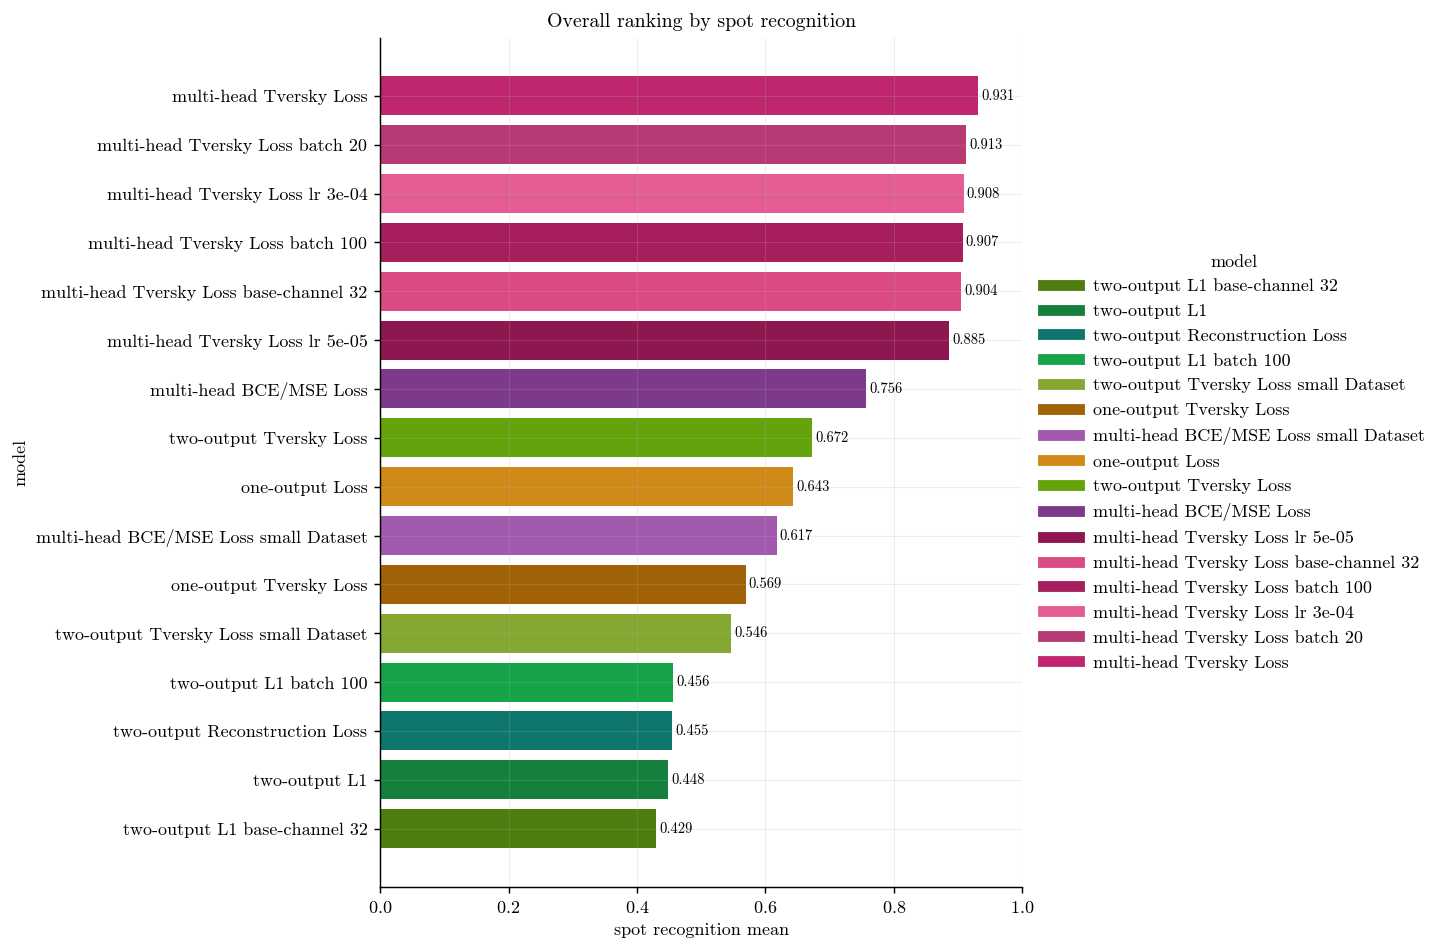

In [18]:
plot_df = rank_df.sort_values(RANK_PRIMARY, ascending=True)
fig, ax = plt.subplots(figsize=(11, max(4, 0.45 * len(plot_df))), constrained_layout=True)
colors = plot_df["model_display"].map(model_color)
ax.barh(plot_df["model_display"], plot_df[RANK_PRIMARY], color=colors)
ax.set_xlabel("spot recognition mean")
ax.set_ylabel("model")
ax.set_xlim(0, max(1.0, plot_df[RANK_PRIMARY].max() * 1.05))
ax.set_title("Overall ranking by spot recognition")
for i, row in plot_df.iterrows():
    ax.text(row[RANK_PRIMARY] + 0.005, row["model_display"], f"{row[RANK_PRIMARY]:.3f}", va="center", fontsize=8)
handles = [plt.Line2D([0], [0], color=model_color(name), lw=6, label=name) for name in plot_df["model_display"]]
ax.legend(handles=handles, title="model", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
savefig(fig, "figure_01_model_ranking")
plt.show()

## Figure 3: Architecture comparison

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved eva_server/model_comparison/allmodels/figures/figure_03_model_metric_comparison.png
saved eva_server/model_comparison/allmodels/figures/figure_03_model_metric_comparison.pdf


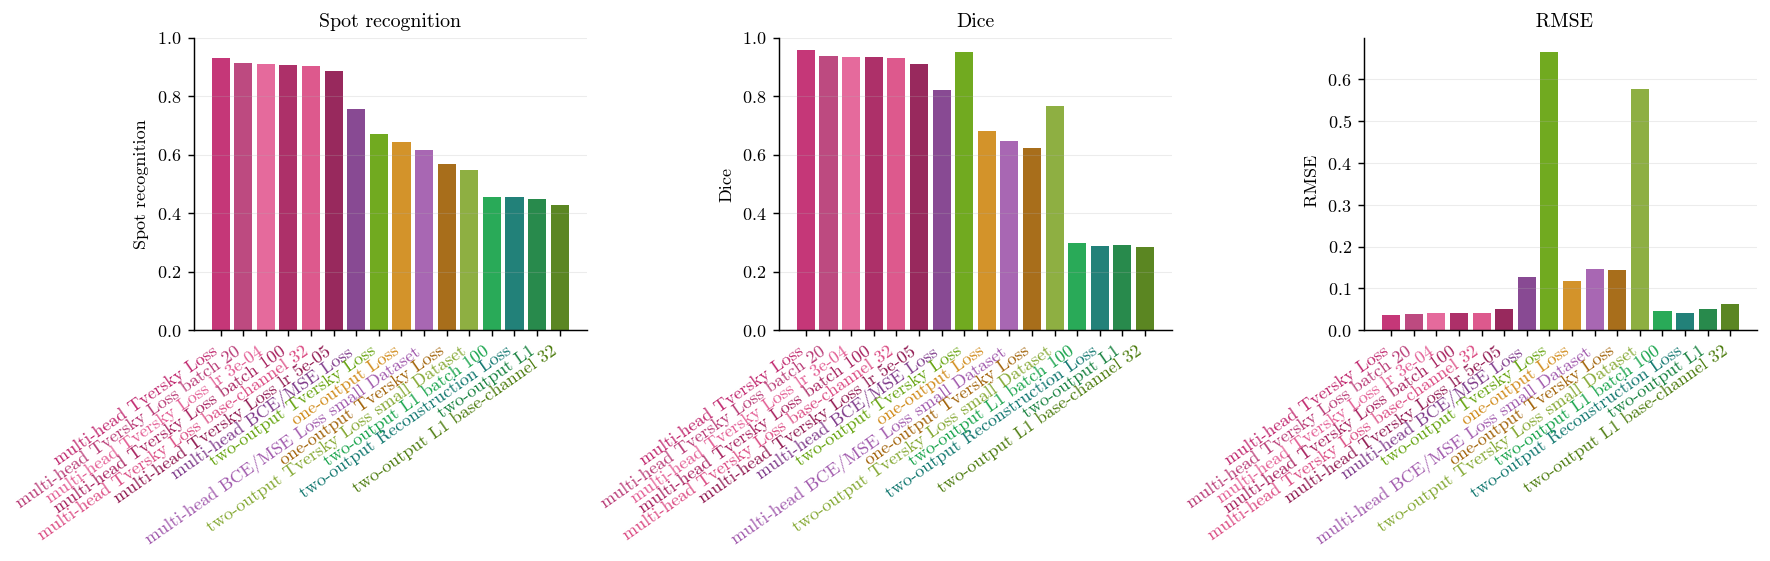

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), constrained_layout=True)
metrics = [("spot_recognition_mean", "Spot recognition"), ("dice_mean", "Dice"), ("rmse_mean", " RMSE")]
plot_models = rank_df.sort_values(RANK_PRIMARY, ascending=False).copy()

for ax, (metric, label) in zip(axes, metrics):
    if metric not in plot_models.columns:
        ax.text(0.5, 0.5, f"No {metric}", ha="center", va="center")
        continue

    metric_df = plot_models.dropna(subset=[metric])
    ax.bar(
        metric_df["model_display"],
        metric_df[metric],
        color=metric_df["model_display"].map(model_color),
        alpha=0.92,
    )
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=35)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
        tick.set_color(model_color(tick.get_text()))
    ax.grid(axis="y", alpha=0.24)
    ax.grid(axis="x", visible=False)
    if "RMSE" not in label:
        ax.set_ylim(0, 1)

savefig(fig, "figure_03_model_metric_comparison")
plt.show()


## Figure 4: Dataset-level comparison

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved eva_server/model_comparison/allmodels/figures/figure_04_dataset_model_heatmap.png
saved eva_server/model_comparison/allmodels/figures/figure_04_dataset_model_heatmap.pdf


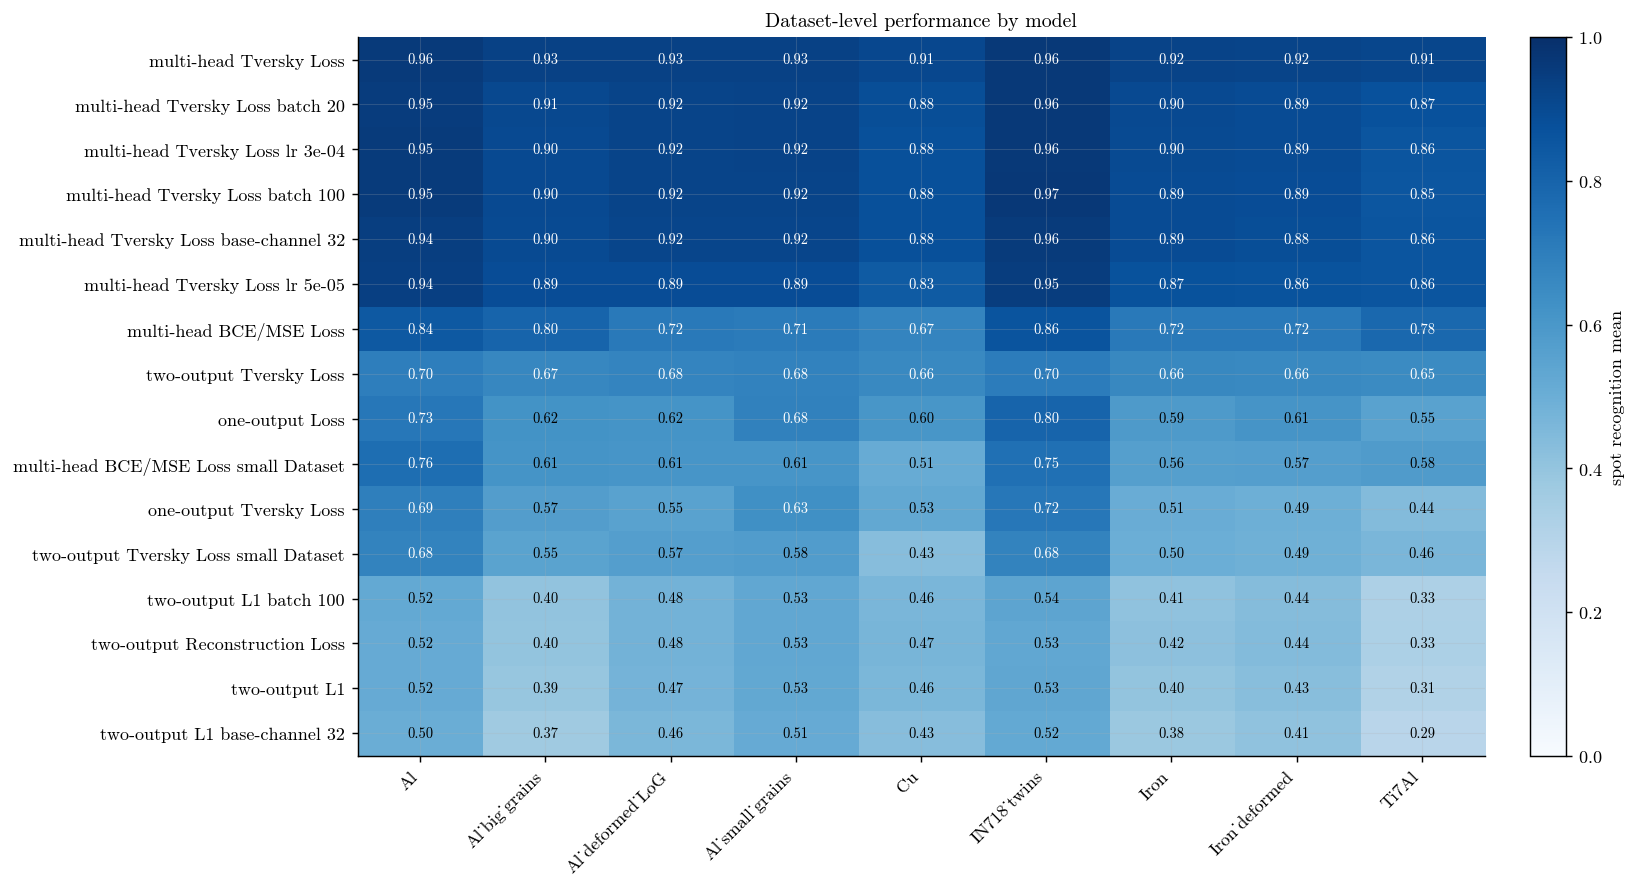

In [20]:
if "dataset" in sample_df.columns:
    dataset_metric = "spot_recognition_mean"
    dataset_table = (
        sample_df.groupby(["model_display", "architecture", "dataset"])[dataset_metric]
        .mean()
        .reset_index()
    )
    pivot = dataset_table.pivot(index="model_display", columns="dataset", values=dataset_metric).loc[rank_df["model_display"]]
    pivot.to_csv(OUTPUT_DIR / "dataset_spot_recognition_matrix.csv")

    fig, ax = plt.subplots(figsize=(12.5, max(5, 0.42 * len(pivot))), constrained_layout=True)
    im = ax.imshow(pivot, cmap=THESIS_BLUE_CMAP, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    for tick in ax.get_yticklabels():
        tick.set_color("black")
    for y in range(pivot.shape[0]):
        for x in range(pivot.shape[1]):
            value = pivot.iloc[y, x]
            if pd.notna(value):
                ax.text(x, y, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.62 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, label="spot recognition mean", location="right", fraction=0.035, pad=0.04)
    ax.set_title("Dataset-level performance by model")
    savefig(fig, "figure_04_dataset_model_heatmap")
    plt.show()
else:
    print("No dataset information available in sample-level metrics.")

## Figure 5: Spot counter comparison

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved eva_server/model_comparison/allmodels/figures/figure_05_spot_counter.png
saved eva_server/model_comparison/allmodels/figures/figure_05_spot_counter.pdf


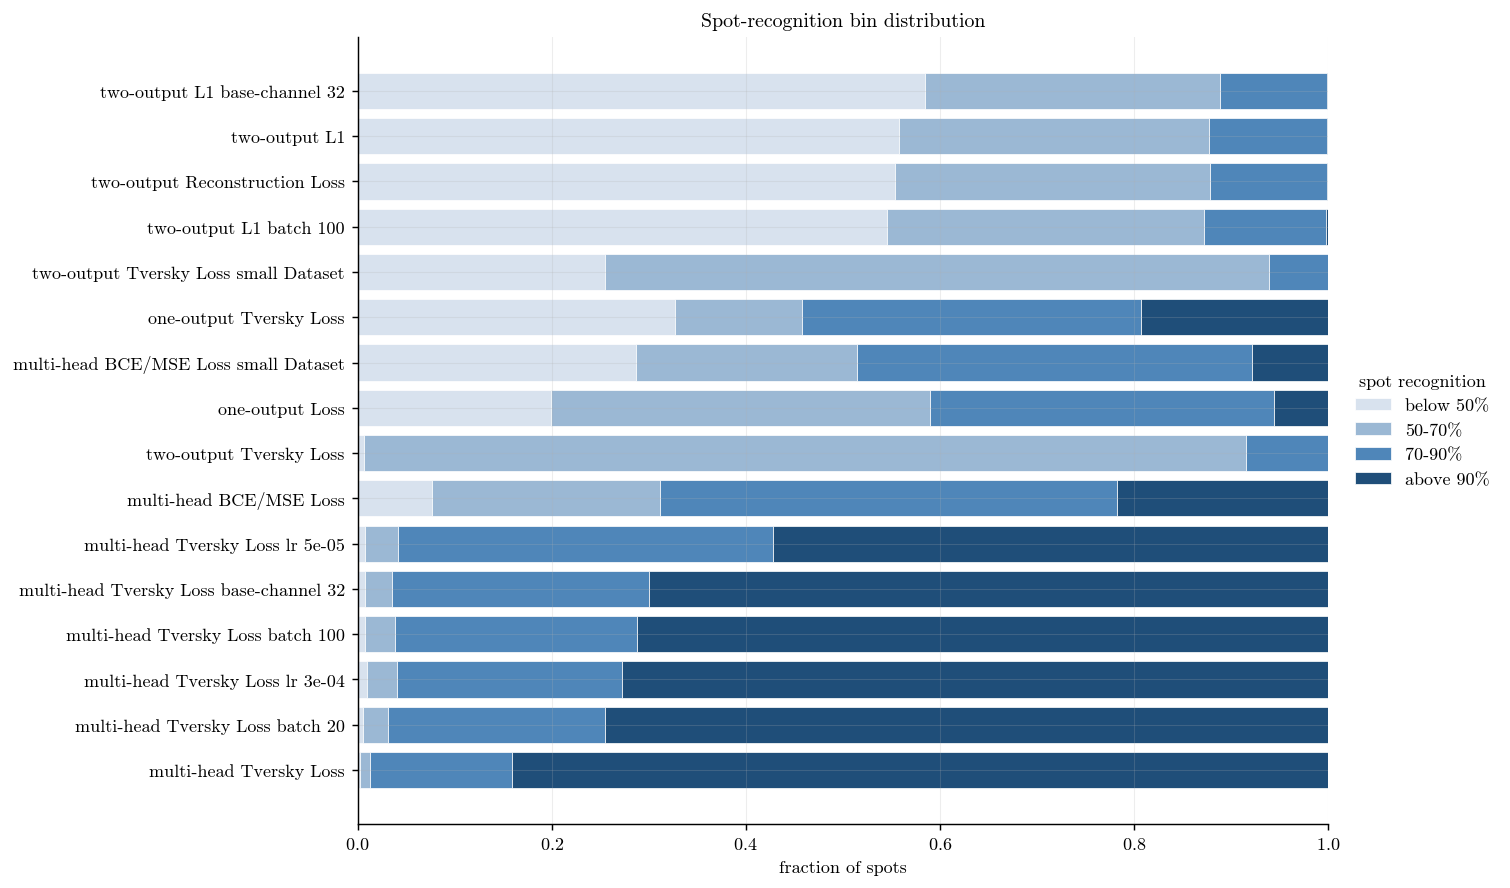

In [21]:
counter_frames = []
for path in files["counter"]:
    df = read_csv_if_nonempty(path)
    if df.empty:
        continue
    source_dir = str(path.parent)
    df["architecture"] = [infer_arch_from_path(source_dir, model) for model in df["model"]]
    df["model_display_base"] = [model_display_name(model, source_dir, arch) for model, arch in zip(df["model"], df["architecture"])]
    df["model_display"] = [
        make_unique_model_display(display, source_dir, AMBIGUOUS_MODEL_LABELS)
        for display in df["model_display_base"]
    ]
    counter_frames.append(df)
counter_df = pd.concat(counter_frames, ignore_index=True) if counter_frames else pd.DataFrame()
if not counter_df.empty:
    counter_df = apply_model_selection_and_renaming(counter_df)

if not counter_df.empty:
    frac_cols = [f"{bin_name}_fraction" for bin_name in SPOT_BIN_ORDER if f"{bin_name}_fraction" in counter_df.columns]
    performance_order = rank_df.sort_values("spot_recognition_mean", ascending=False)["model_display"]
    counter_plot = counter_df.set_index("model_display").reindex(performance_order)[frac_cols].fillna(0)
    fig, ax = plt.subplots(figsize=(11.5, max(4, 0.42 * len(counter_plot))), constrained_layout=True)
    left = np.zeros(len(counter_plot))
    for col in frac_cols:
        ax.barh(
            counter_plot.index,
            counter_plot[col],
            left=left,
            color=SPOT_BIN_COLORS.get(col, COLOR["gray"]),
            label=SPOT_BIN_LABELS.get(col, col.replace("_fraction", "")),
            edgecolor="white",
            linewidth=0.4,
        )
        left += counter_plot[col].to_numpy()
    ax.set_xlim(0, 1)
    ax.set_xlabel("fraction of spots")
    ax.set_title("Spot-recognition bin distribution")
    for tick in ax.get_yticklabels():
        tick.set_color("black")
    ax.legend(title="spot recognition", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    savefig(fig, "figure_05_spot_counter")
    plt.show()
else:
    print("No spot counter files found.")


## Figure 6: Runtime vs quality

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved eva_server/model_comparison/allmodels/figures/figure_06_runtime_vs_quality.png
saved eva_server/model_comparison/allmodels/figures/figure_06_runtime_vs_quality.pdf


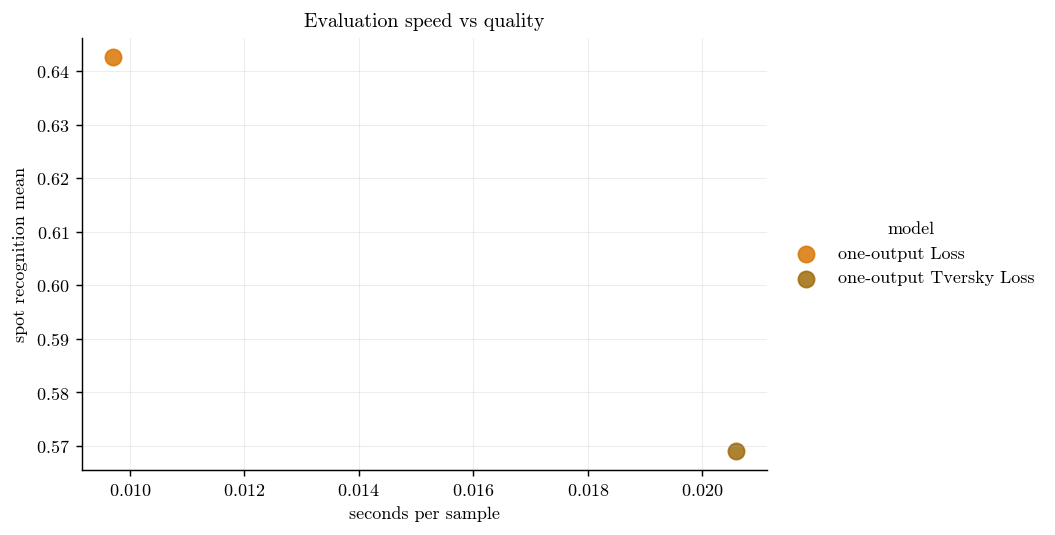

In [28]:
if "seconds_per_sample" in rank_df.columns and rank_df["seconds_per_sample"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    for _, row in rank_df.dropna(subset=["seconds_per_sample", RANK_PRIMARY]).iterrows():
        ax.scatter(
            row["seconds_per_sample"],
            row[RANK_PRIMARY],
            s=80,
            alpha=0.85,
            color=model_color(row["model_display"]),
            label=row["model_display"],
        )
        #ax.text(row["seconds_per_sample"], row[RANK_PRIMARY], "  " + row["model_display"], va="center", fontsize=8)
    ax.set_xlabel("seconds per sample")
    ax.set_ylabel("spot recognition mean")
    ax.set_title("Evaluation speed vs quality")
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), title="model", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    savefig(fig, "figure_06_runtime_vs_quality")
    plt.show()
else:
    print("No timing information available.")

## Final Top 3

In [29]:
print("Top 3 models by spot_recognition_mean")
display(top3)
for _, row in top3.iterrows():
    print(f"#{int(row['rank'])}: {row['model_display']} | {row['architecture']} | recognition={row['spot_recognition_mean']:.4f} | dice={row['dice_mean']:.4f} | IoU={row['iou_mean']:.4f}")

Top 3 models by spot_recognition_mean


,rank,model_display,architecture,spot_recognition_mean,dice_mean,iou_mean,rmse_mean,nrmse_mean,soft_intensity_dice_mean,integrated_intensity_abs_relative_error_mean,seconds_per_sample,n_samples,model,source_dir
0,1,one-output Loss,oneoutput,0.642630,0.681937,0.546975,0.118094,0.475481,0.860408,0.194841,0.009709,5000,final_20260702-145153_augmented_spots_train_e2...,eva_server/evaluation/oneoutput/0702_oneoutput
1,2,one-output Tversky Loss,oneoutput,0.569106,0.621764,0.557749,0.143895,0.555721,0.640464,0.464249,0.020585,5000,final_20260727-152943_oneoutput_augmented_spot...,eva_server/evaluation/oneoutput/tversky


#1: one-output Loss | oneoutput | recognition=0.6426 | dice=0.6819 | IoU=0.5470
#2: one-output Tversky Loss | oneoutput | recognition=0.5691 | dice=0.6218 | IoU=0.5577
